In [5]:
#Python v3.10.11
#Import necessary packages

import os
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import matplotlib.image as mpimg
import matplotlib as mpl

sys.path.append('functions')

from death_prediction_functions import time_to_death_grouped, cross_validation, train_nn, generate_nn_pred
from gene_analysis_functions import get_great, get_cistrome, get_pos, insig_nan

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
#set directory and get relevant files

os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/model_outputs')
death_pvals = pd.read_excel('death_classifier_probes.xlsx', index_col=0)
pinv_pvals = pd.read_excel('pseudoinverse_probes_filtered.xlsx', index_col=0)

In [21]:
#blood glucose probes

GLU_probes = pinv_pvals['M10_poststress_GLU_pval']
GLU_probes = GLU_probes.dropna()
GLU_probes = GLU_probes[GLU_probes<0.01]
GLU_probes = list(GLU_probes.index)

#aging probes
age_probes = death_pvals
age_probes = age_probes.dropna()
age_probes = list(age_probes.index)

intersections = list(set(GLU_probes) & set(age_probes))
cross_identified_probes = death_pvals.loc[intersections]
cross_identified_probes = cross_identified_probes[['coef', 'associated_genes']]

cross_identified_probes = cross_identified_probes.rename_axis('ID').reset_index()

cross_identified_probes

,ID,coef,associated_genes
0,cg35891694_BC21,0.115852,"Mbd2 (-20,881), Poli (-16,688)"
1,cg33753816_TC21,-0.023822,"Gm8888 (-234,493), Slc38a4 (+54,322)"
2,cg33480444_BC22,0.049532,"Gm6569 (-24,652), Ptp4a3 (+84,979)"
3,cg32450306_TC21,0.087063,"Tmem260 (-234,462), Peli2 (+91,051)"
4,cg41245575_BC21,-0.007811,"Acot11 (-54,939), Ssbp3 (-51,533)"
5,cg42195342_TC21,0.031047,"G6pd2 (-172,581)"
6,cg32213071_BC21,0.033697,"Lrrc3b (-598,299), Ngly1 (-211,994)"
7,cg35211400_BC21,0.027809,"Ltbp1 (-194,374), Ttc27 (+93,444)"
8,cg30200424_BC11,-0.048320,"Sdk2 (-582,358), Rpl38 (-20,033)"
9,cg35206479_TC21,0.024336,"Memo1 (-18,693), Dpy30 (+10,368)"


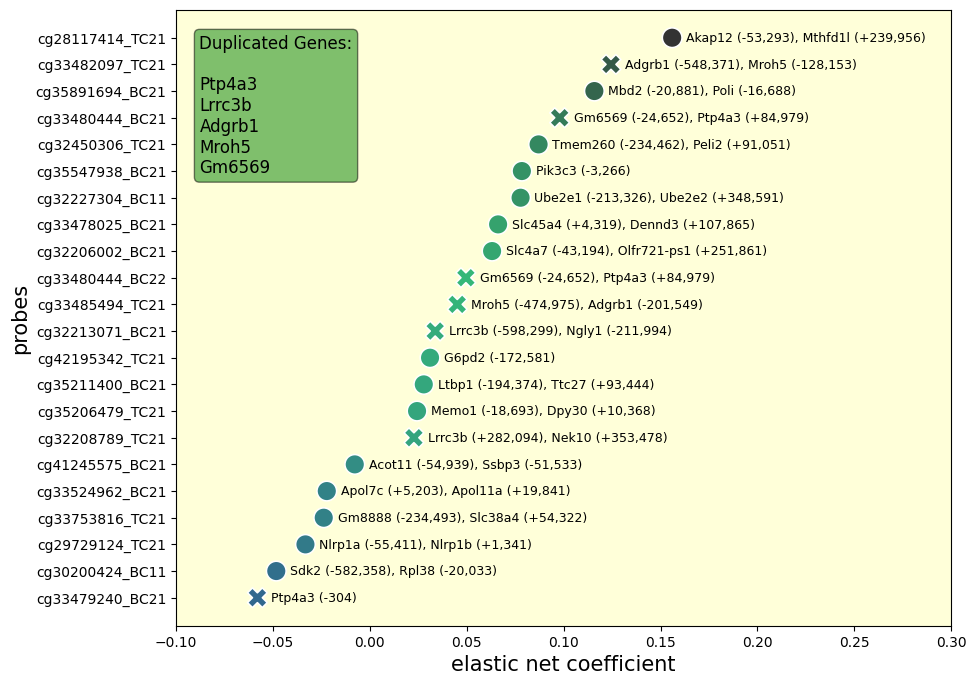

In [40]:
# Extract genes from associated_genes column
def extract_genes(gene_string):

    genes = []
    n_genes = gene_string.count(', ')
    n = 0

    while n < n_genes+1:
        index_space = gene_string.find(' ')
        gene_n = gene_string[:index_space]
        genes.append(gene_n)

        index_comma = gene_string.find(', ')
        gene_string = gene_string[index_comma+2:]

        n+=1

    return genes

#sort elastic net by value so the legend isn't obscured
cross_identified_probes = cross_identified_probes.sort_values(by='coef', ascending=False, ignore_index=True)

# Apply the function to each entry in 'associated_genes' column
associated_genes_full = [gene for gene in cross_identified_probes['associated_genes']]
cross_identified_probes['genes'] = cross_identified_probes['associated_genes'].apply(extract_genes)

# Count occurrences of each gene across all entries
gene_counts = pd.Series([gene for genes_list in cross_identified_probes['genes'] for gene in genes_list]).value_counts()

# Define marker style based on duplication status
duplicates = gene_counts[gene_counts > 1].index.tolist()

marker_style = []
for genes in cross_identified_probes['associated_genes']:
    to_append = '^'
    for gene in duplicates:
        if gene in genes:
            to_append = 'o'
        else: pass
    marker_style.append(to_append)
    
# Create the scatterplot with emphasized duplicated genes
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=cross_identified_probes, x='coef', y='ID', style=marker_style, s=200, 
                palette='viridis_d', hue='coef', legend=False)

#add legend showing repeated genes
props = dict(boxstyle='round', facecolor='green', alpha=0.5)

gene_list_formatted = '\n'.join(duplicates)
plt.text(0.03, 0.96, f'Duplicated Genes:\n\n{gene_list_formatted}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

# Annotate each point with associated genes
for i, genes in enumerate(associated_genes_full):
    x = cross_identified_probes['coef'][i]
    y = cross_identified_probes.index[i]
    ax.annotate(genes, (x, y), textcoords="offset points", xytext=(10, -3), ha='left', size=9)

plt.xlabel('elastic net coefficient', size=15)
plt.ylabel('probes', size=15)

ax.set_facecolor((1, 1, 0.8509803921)) #same as plot included in same figure
plt.xlim(-0.1, 0.3)

plt.show() #only cg35211400_BC21 selected by M12